# Chapter 4: Empirical Results & Analysis
## Research Question 2: Financial & Computational Cost & Efficiency Analysis

This notebook analyzes raw operational resource expenditures (**Training Time**, **Inference Latency**, **Inference Throughput**, **Peak VRAM**, **Training Energy**, **Inference Energy**, and **Monetary Cost per 1k Inferences**), visualizes **Training vs VRAM Hardware Tiers** (Figure 4.3), **Unified Inference Throughput Across All Datasets** (Figure 4.4), **Cost Efficiency Metrics (Accuracy & Macro F1)**, and **Unified Cost vs. Macro F1 Pareto Frontiers Across All Datasets** (Figure 4.5).


In [1]:
import sys
import os
import pandas as pd
from IPython.display import display, Image

# Import analysis helper utilities
sys.path.append('.')
from analysis_utils import (
    load_all_results, 
    create_dataset_cost_table,
    plot_dual_panel_cost,
    plot_inference_throughput,
    create_cost_efficiency_table,
    plot_pareto_cost_vs_accuracy
)

# Load data from structured results directory
RESULTS_DIR = "../results_by_model"
df = load_all_results(RESULTS_DIR)
print(f"Loaded {len(df)} experiment evaluations.")


Saved aggregated performance results to CSV: /home/vvet/Documents/Dissertation/Experiments/results/all_results.csv
Loaded 67 experiment evaluations.


### 2.1 Cost Breakdown Tables
Call `create_dataset_cost_table(df, dataset_name)` for each dataset (`'20_newsgroups'`, `'ag_news'`, `'banking77'`, `'emotion'`) to view:
`Model` | `Train time (s)` | `Inf. latency (ms/sample)` | `Throughput (s/s)` | `Peak VRAM (MB)` | `Energy train (Wh)` | `Energy inf (Wh)` | `Monetary cost ($/1k inf)`.


In [2]:
print("=== TABLE 4.3a: COST & RESOURCE BREAKDOWN — 20 NEWSGROUPS ===")
cost_20news = create_dataset_cost_table(df, '20_newsgroups')
display(cost_20news)


=== TABLE 4.3a: COST & RESOURCE BREAKDOWN — 20 NEWSGROUPS ===


Train time (s)  \
Paradigm            Model                                     
Encoder Fine-Tuning BERT-base                         424.2   
                    DistilBERT-base                   213.7   
                    RoBERTa-base                      424.6   
Local QLoRA         Llama-3.1-8B (QLoRA)           34,612.4   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)             N/A   
                    Llama-3.1-8B (Zero-Shot)            N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)             N/A   
                    GPT-5.6-luna (Zero-Shot)            N/A   

                                             Inf. latency (ms/sample)  \
Paradigm            Model                                               
Encoder Fine-Tuning BERT-base                                    3.43   
                    DistilBERT-base                              1.71   
                    RoBERTa-base                                 3.40   
Local QLoRA         Llama-3.1-8B (QLoRA)                       325.27   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                   1174.96   
                    Llama-3.1-8B (Zero-Shot)                   298.38   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                   1308.70   
                    GPT-5.6-luna (Zero-Shot)                  1210.33   

                                             Throughput (s/s) Peak VRAM (MB)  \
Paradigm            Model                                                      
Encoder Fine-Tuning BERT-base                           291.3          1,667   
                    DistilBERT-base                     585.0          1,058   
                    RoBERTa-base                        293.7          1,843   
Local QLoRA         Llama-3.1-8B (QLoRA)                  3.1          6,262   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)               0.9         33,725   
                    Llama-3.1-8B (Zero-Shot)              3.4         32,983   
Cloud API LLM       GPT-5.6-luna (Few-Shot)               0.8            N/A   
                    GPT-5.6-luna (Zero-Shot)              0.8            N/A   

                                             Energy train (Wh)  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                              5.9   
                    DistilBERT-base                        2.6   
                    RoBERTa-base                           5.9   
Local QLoRA         Llama-3.1-8B (QLoRA)                 545.0   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                N/A   
                    Llama-3.1-8B (Zero-Shot)               N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                N/A   
                    GPT-5.6-luna (Zero-Shot)               N/A   

                                             Energy inf (Wh)  \
Paradigm            Model                                      
Encoder Fine-Tuning BERT-base                         0.4334   
                    DistilBERT-base                   0.1984   
                    RoBERTa-base                      0.4044   
Local QLoRA         Llama-3.1-8B (QLoRA)             41.4150   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)         170.4002   
                    Llama-3.1-8B (Zero-Shot)         35.7570   
Cloud API LLM       GPT-5.6-luna (Few-Shot)              N/A   
                    GPT-5.6-luna (Zero-Shot)             N/A   

                                             Monetary cost ($/1k inf)  
Paradigm            Model                                              
Encoder Fine-Tuning BERT-base                               $0.000009  
                    DistilBERT-base                         $0.000004  
                    RoBERTa-base                            $0.000008  
Local QLoRA         Llama-3.1-8B (QLoRA)                    $0.000851  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                 $0.003503  
                    Llama-3.1-8B (Zero-Shot)                $0.000735  
Clou

In [3]:
print("=== TABLE 4.3b: COST & RESOURCE BREAKDOWN — AG NEWS ===")
cost_agnews = create_dataset_cost_table(df, 'ag_news')
display(cost_agnews)


=== TABLE 4.3b: COST & RESOURCE BREAKDOWN — AG NEWS ===


Train time (s)  \
Paradigm            Model                                     
Encoder Fine-Tuning BERT-base                       1,129.2   
                    DistilBERT-base                   629.7   
                    RoBERTa-base                    1,173.3   
Local QLoRA         Llama-3.1-8B (QLoRA)           64,687.8   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)             N/A   
                    Llama-3.1-8B (Zero-Shot)            N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)             N/A   
                    GPT-5.6-luna (Zero-Shot)            N/A   

                                             Inf. latency (ms/sample)  \
Paradigm            Model                                               
Encoder Fine-Tuning BERT-base                                    0.52   
                    DistilBERT-base                              0.28   
                    RoBERTa-base                                 0.52   
Local QLoRA         Llama-3.1-8B (QLoRA)                        59.55   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                    266.22   
                    Llama-3.1-8B (Zero-Shot)                   222.00   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                   1075.89   
                    GPT-5.6-luna (Zero-Shot)                   991.95   

                                             Throughput (s/s) Peak VRAM (MB)  \
Paradigm            Model                                                      
Encoder Fine-Tuning BERT-base                         1,921.8          1,501   
                    DistilBERT-base                   3,537.7            906   
                    RoBERTa-base                      1,930.5          1,670   
Local QLoRA         Llama-3.1-8B (QLoRA)                 16.8          5,892   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)               3.8          5,688   
                    Llama-3.1-8B (Zero-Shot)              4.5          5,635   
Cloud API LLM       GPT-5.6-luna (Few-Shot)               0.9            N/A   
                    GPT-5.6-luna (Zero-Shot)              1.0            N/A   

                                             Energy train (Wh)  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                             10.9   
                    DistilBERT-base                        6.1   
                    RoBERTa-base                          11.5   
Local QLoRA         Llama-3.1-8B (QLoRA)               1,021.2   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                N/A   
                    Llama-3.1-8B (Zero-Shot)               N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                N/A   
                    GPT-5.6-luna (Zero-Shot)               N/A   

                                             Energy inf (Wh)  \
Paradigm            Model                                      
Encoder Fine-Tuning BERT-base                         0.0483   
                    DistilBERT-base                   0.0233   
                    RoBERTa-base                      0.0463   
Local QLoRA         Llama-3.1-8B (QLoRA)              7.3077   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)          30.3918   
                    Llama-3.1-8B (Zero-Shot)         21.8954   
Cloud API LLM       GPT-5.6-luna (Few-Shot)              N/A   
                    GPT-5.6-luna (Zero-Shot)             N/A   

                                             Monetary cost ($/1k inf)  
Paradigm            Model                                              
Encoder Fine-Tuning BERT-base                               $0.000001  
                    DistilBERT-base                         $0.000000  
                    RoBERTa-base                            $0.000001  
Local QLoRA         Llama-3.1-8B (QLoRA)                    $0.000144  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                 $0.000600  
                    Llama-3.1-8B (Zero-Shot)                $0.000432  
Clou

In [4]:
print("=== TABLE 4.3c: COST & RESOURCE BREAKDOWN — BANKING77 ===")
cost_banking = create_dataset_cost_table(df, 'banking77')
display(cost_banking)


=== TABLE 4.3c: COST & RESOURCE BREAKDOWN — BANKING77 ===


Train time (s)  \
Paradigm            Model                                     
Encoder Fine-Tuning BERT-base                         104.4   
                    DistilBERT-base                    60.7   
                    RoBERTa-base                      106.1   
Local QLoRA         Llama-3.1-8B (QLoRA)            5,383.7   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)             N/A   
                    Llama-3.1-8B (Zero-Shot)            N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)             N/A   
                    GPT-5.6-luna (Zero-Shot)            N/A   

                                             Inf. latency (ms/sample)  \
Paradigm            Model                                               
Encoder Fine-Tuning BERT-base                                    0.53   
                    DistilBERT-base                              0.30   
                    RoBERTa-base                                 0.53   
Local QLoRA         Llama-3.1-8B (QLoRA)                        59.63   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                    984.05   
                    Llama-3.1-8B (Zero-Shot)                   286.82   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                   1096.45   
                    GPT-5.6-luna (Zero-Shot)                  1096.88   

                                             Throughput (s/s) Peak VRAM (MB)  \
Paradigm            Model                                                      
Encoder Fine-Tuning BERT-base                         1,895.1          1,503   
                    DistilBERT-base                   3,311.3            908   
                    RoBERTa-base                      1,885.6          1,672   
Local QLoRA         Llama-3.1-8B (QLoRA)                 16.8          5,896   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)               1.0          6,181   
                    Llama-3.1-8B (Zero-Shot)              3.5          5,718   
Cloud API LLM       GPT-5.6-luna (Few-Shot)               0.9            N/A   
                    GPT-5.6-luna (Zero-Shot)              0.9            N/A   

                                             Energy train (Wh)  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                              0.8   
                    DistilBERT-base                        0.5   
                    RoBERTa-base                           0.9   
Local QLoRA         Llama-3.1-8B (QLoRA)                  86.6   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                N/A   
                    Llama-3.1-8B (Zero-Shot)               N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                N/A   
                    GPT-5.6-luna (Zero-Shot)               N/A   

                                             Energy inf (Wh)  \
Paradigm            Model                                      
Encoder Fine-Tuning BERT-base                         0.0151   
                    DistilBERT-base                   0.0070   
                    RoBERTa-base                      0.0163   
Local QLoRA         Llama-3.1-8B (QLoRA)              3.1155   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)          62.0945   
                    Llama-3.1-8B (Zero-Shot)         15.9761   
Cloud API LLM       GPT-5.6-luna (Few-Shot)              N/A   
                    GPT-5.6-luna (Zero-Shot)             N/A   

                                             Monetary cost ($/1k inf)  
Paradigm            Model                                              
Encoder Fine-Tuning BERT-base                               $0.000001  
                    DistilBERT-base                         $0.000000  
                    RoBERTa-base                            $0.000001  
Local QLoRA         Llama-3.1-8B (QLoRA)                    $0.000152  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                 $0.003028  
                    Llama-3.1-8B (Zero-Shot)                $0.000779  
Clou

In [5]:
print("=== TABLE 4.3d: COST & RESOURCE BREAKDOWN — EMOTION ===")
cost_emotion = create_dataset_cost_table(df, 'emotion')
display(cost_emotion)


=== TABLE 4.3d: COST & RESOURCE BREAKDOWN — EMOTION ===


Train time (s)  \
Paradigm            Model                                     
Encoder Fine-Tuning BERT-base                         181.8   
                    DistilBERT-base                    92.2   
                    RoBERTa-base                      180.1   
Local QLoRA         Llama-3.1-8B (QLoRA)            9,666.4   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)             N/A   
                    Llama-3.1-8B (Zero-Shot)            N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)             N/A   
                    GPT-5.6-luna (Zero-Shot)            N/A   

                                             Inf. latency (ms/sample)  \
Paradigm            Model                                               
Encoder Fine-Tuning BERT-base                                    0.52   
                    DistilBERT-base                              0.22   
                    RoBERTa-base                                 0.53   
Local QLoRA         Llama-3.1-8B (QLoRA)                        60.33   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                    257.01   
                    Llama-3.1-8B (Zero-Shot)                   212.79   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                   1079.98   
                    GPT-5.6-luna (Zero-Shot)                  1213.05   

                                             Throughput (s/s) Peak VRAM (MB)  \
Paradigm            Model                                                      
Encoder Fine-Tuning BERT-base                         1,920.6          1,504   
                    DistilBERT-base                   4,576.7            680   
                    RoBERTa-base                      1,884.4          1,670   
Local QLoRA         Llama-3.1-8B (QLoRA)                 16.6          5,892   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)               3.9          5,660   
                    Llama-3.1-8B (Zero-Shot)              4.7          5,606   
Cloud API LLM       GPT-5.6-luna (Few-Shot)               0.9            N/A   
                    GPT-5.6-luna (Zero-Shot)              0.8            N/A   

                                             Energy train (Wh)  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                              1.6   
                    DistilBERT-base                        0.8   
                    RoBERTa-base                           1.7   
Local QLoRA         Llama-3.1-8B (QLoRA)                 154.0   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                N/A   
                    Llama-3.1-8B (Zero-Shot)               N/A   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                N/A   
                    GPT-5.6-luna (Zero-Shot)               N/A   

                                             Energy inf (Wh)  \
Paradigm            Model                                      
Encoder Fine-Tuning BERT-base                         0.2671   
                    DistilBERT-base                   0.0027   
                    RoBERTa-base                      0.0093   
Local QLoRA         Llama-3.1-8B (QLoRA)              2.0369   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)           8.0625   
                    Llama-3.1-8B (Zero-Shot)          5.6509   
Cloud API LLM       GPT-5.6-luna (Few-Shot)              N/A   
                    GPT-5.6-luna (Zero-Shot)             N/A   

                                             Monetary cost ($/1k inf)  
Paradigm            Model                                              
Encoder Fine-Tuning BERT-base                               $0.000001  
                    DistilBERT-base                         $0.000000  
                    RoBERTa-base                            $0.000001  
Local QLoRA         Llama-3.1-8B (QLoRA)                    $0.000153  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                 $0.000605  
                    Llama-3.1-8B (Zero-Shot)                $0.000424  
Clou

### 2.2 Figure 4.3: Training Duration & Peak VRAM Hardware Tiers (Dual-Panel)
- **Left panel**: Horizontal bar chart of Training Duration (s) on $\log_{10}$ scale.
- **Right panel**: Peak VRAM footprint (GB) with reference capacity lines at 8GB (RTX 4060), 16GB (RTX 4080), and 24GB (RTX 3090/4090).


Saved Dual-Panel Cost Figure to: ../results/plots/fig4_3_dual_panel_20_newsgroups.png


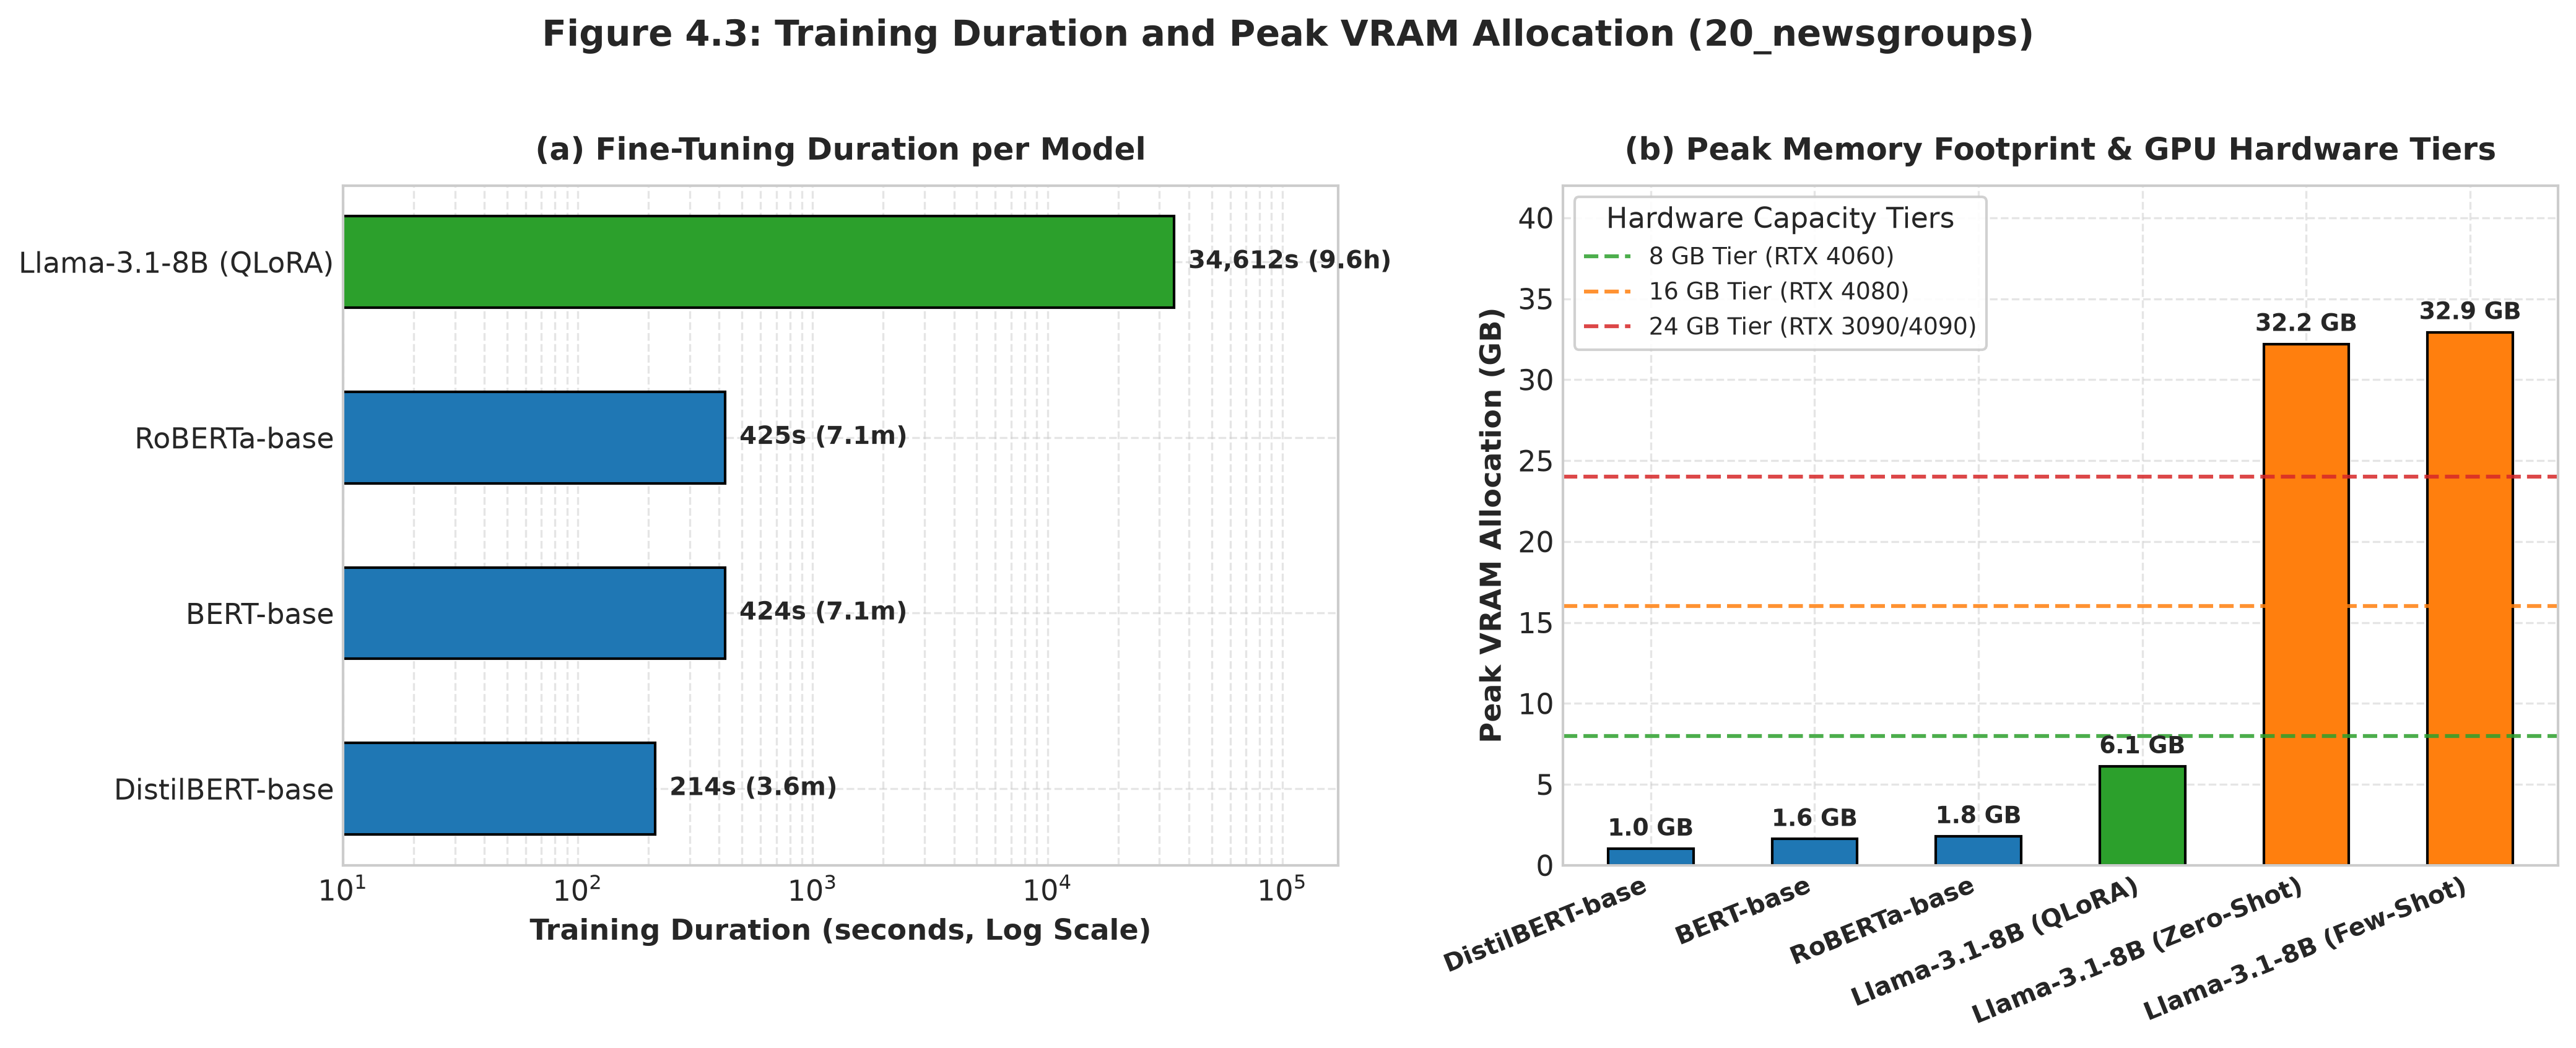

In [6]:
fig_dual_20news = "../results/plots/fig4_3_dual_panel_20_newsgroups.png"
plot_dual_panel_cost(df, '20_newsgroups', output_path=fig_dual_20news)
display(Image(filename=fig_dual_20news))


Saved Dual-Panel Cost Figure to: ../results/plots/fig4_3_dual_panel_ag_news.png


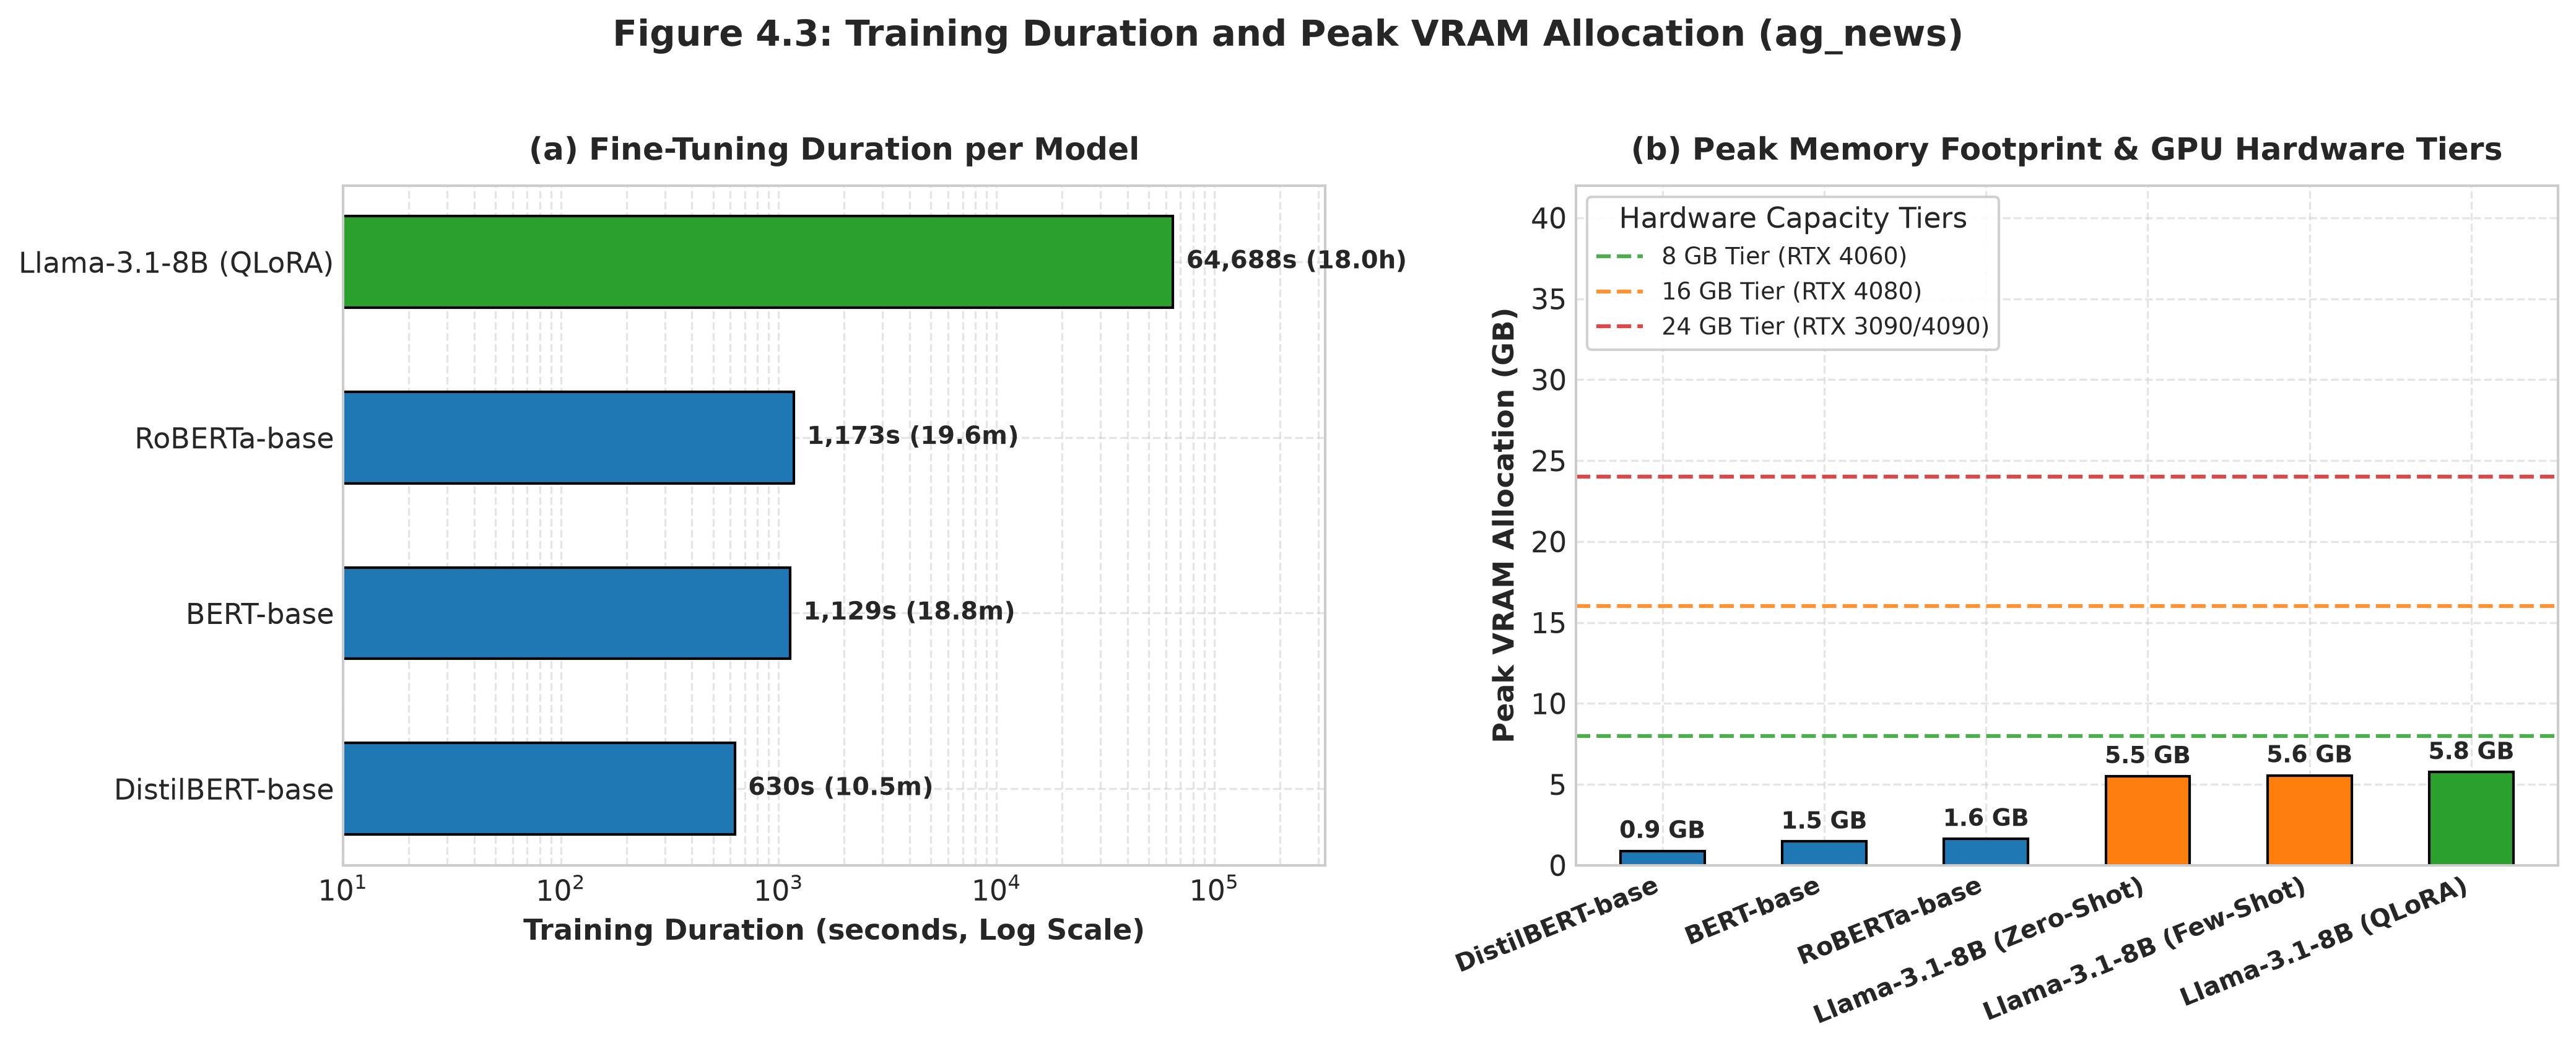

In [7]:
fig_dual_agnews = "../results/plots/fig4_3_dual_panel_ag_news.png"
plot_dual_panel_cost(df, 'ag_news', output_path=fig_dual_agnews)
display(Image(filename=fig_dual_agnews))


Saved Dual-Panel Cost Figure to: ../results/plots/fig4_3_dual_panel_banking77.png


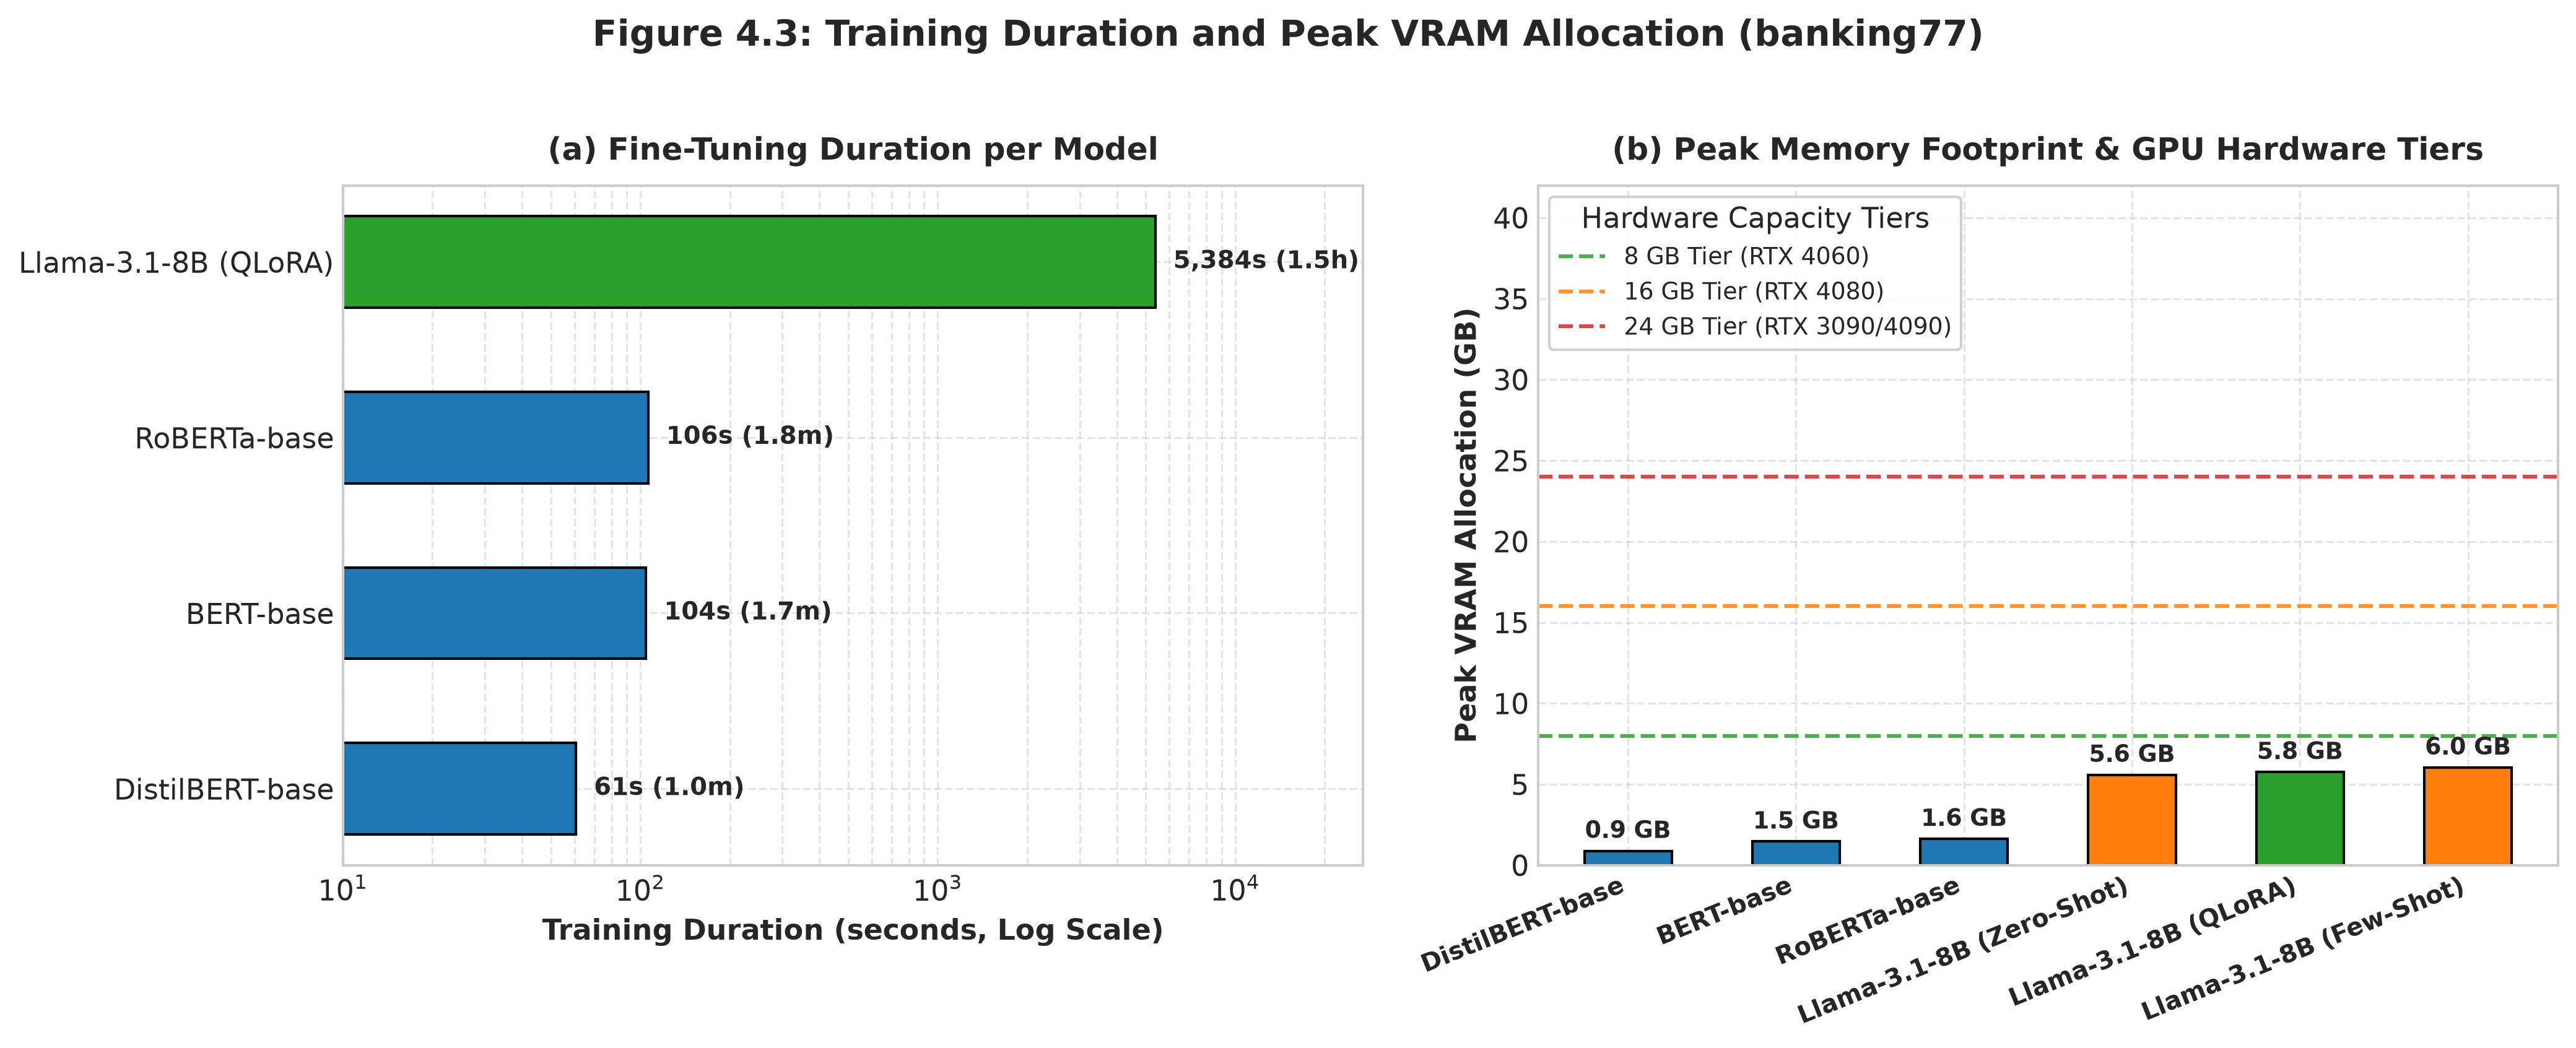

In [8]:
fig_dual_banking = "../results/plots/fig4_3_dual_panel_banking77.png"
plot_dual_panel_cost(df, 'banking77', output_path=fig_dual_banking)
display(Image(filename=fig_dual_banking))


Saved Dual-Panel Cost Figure to: ../results/plots/fig4_3_dual_panel_emotion.png


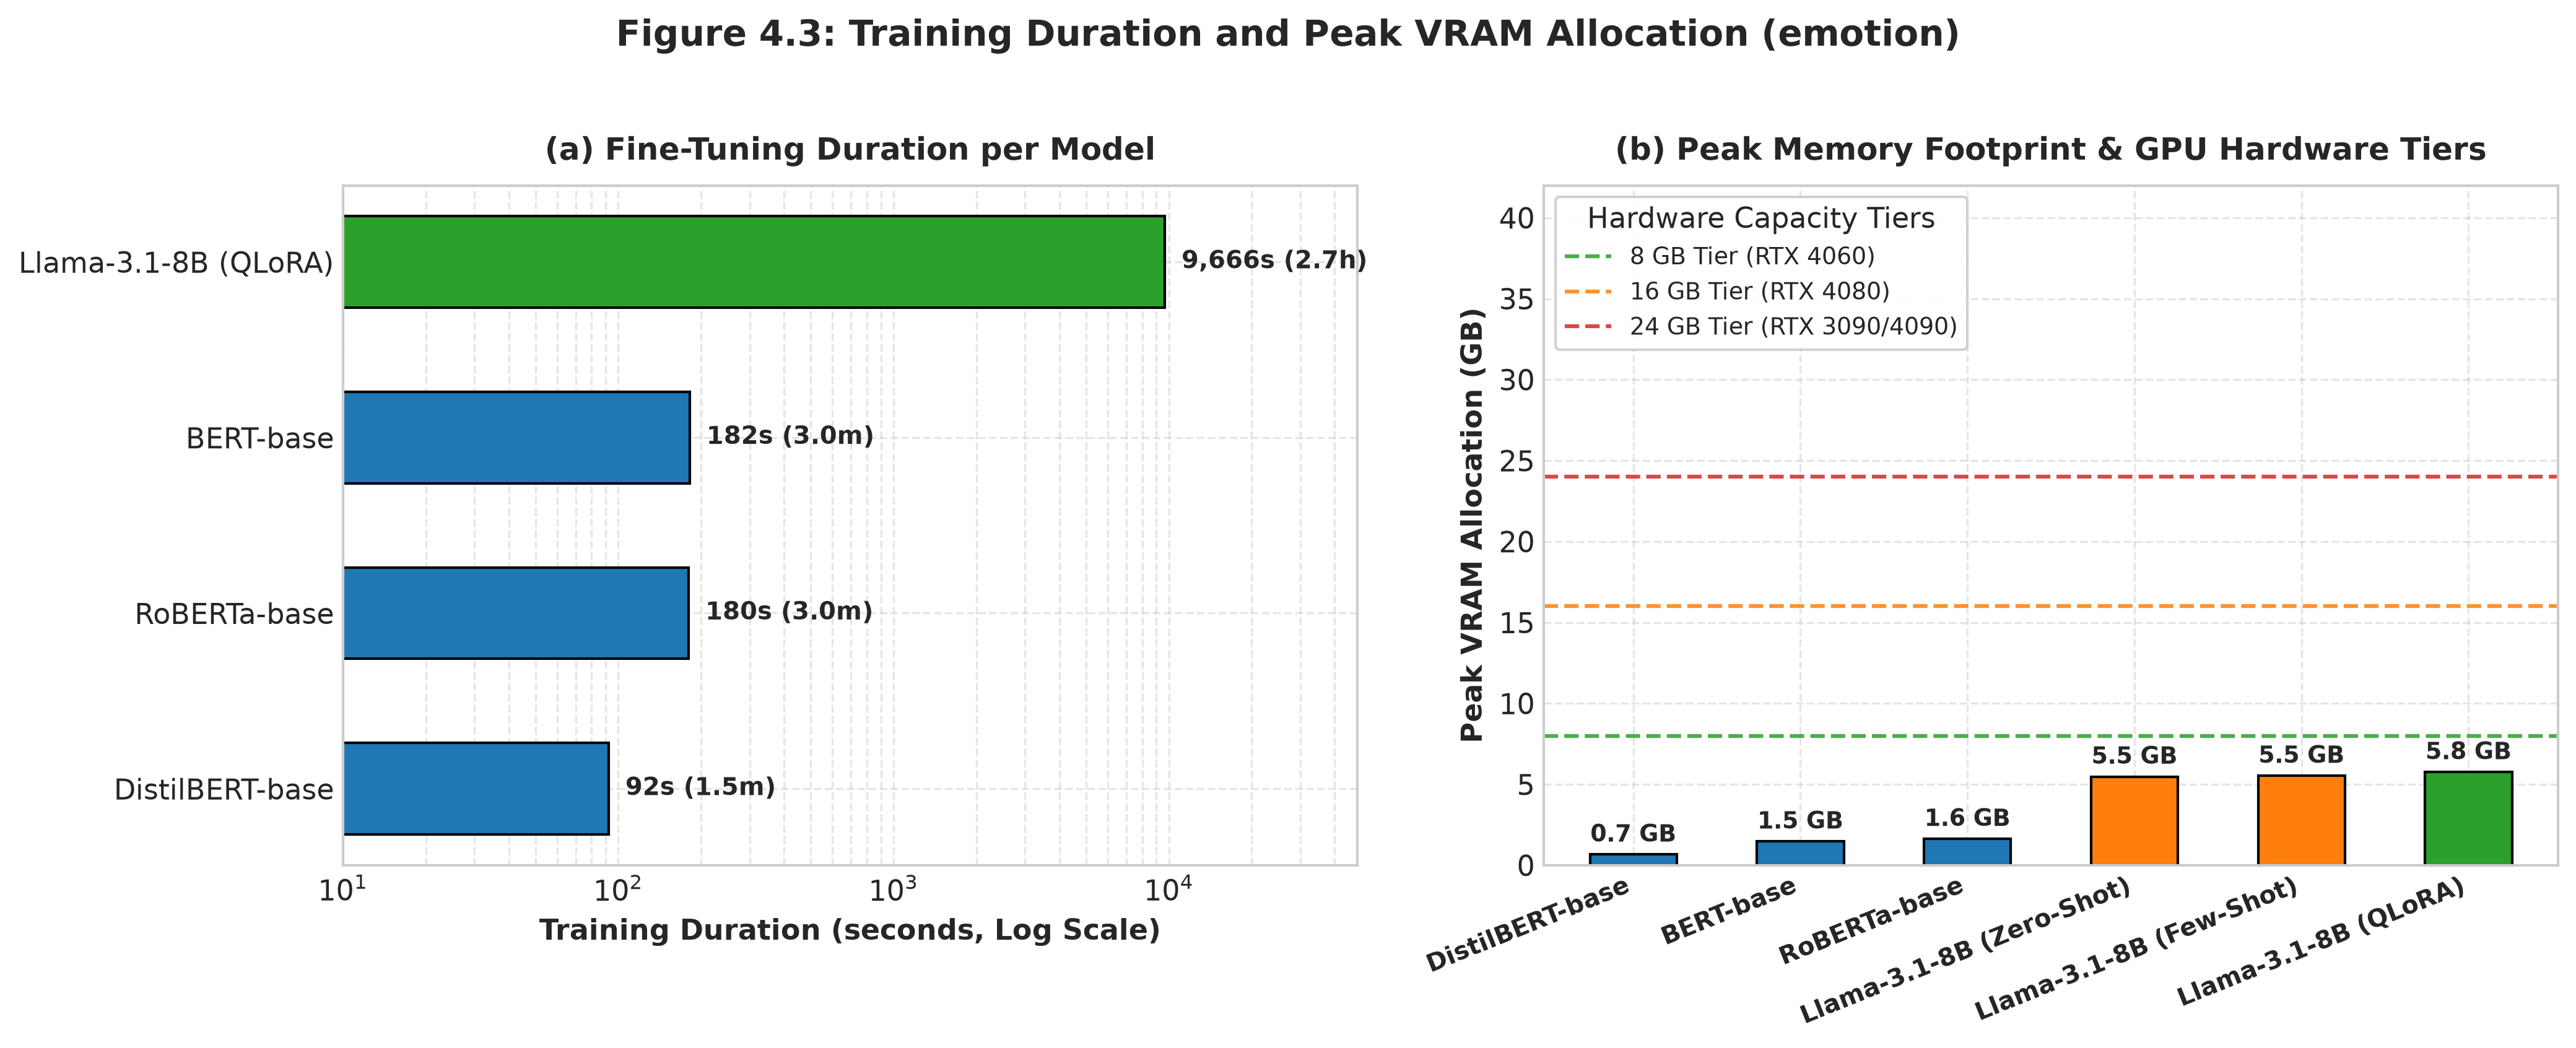

In [9]:
fig_dual_emotion = "../results/plots/fig4_3_dual_panel_emotion.png"
plot_dual_panel_cost(df, 'emotion', output_path=fig_dual_emotion)
display(Image(filename=fig_dual_emotion))


### 2.3 Figure 4.4: Inference Throughput Across Model Paradigms (All Datasets)
Unified multi-panel diagram displaying Inference Throughput (samples/second) on a $\log_{10}$ scale across all four datasets in one place.


Saved Unified Throughput Figure to: ../results/plots/fig4_4_throughput_all_datasets.png


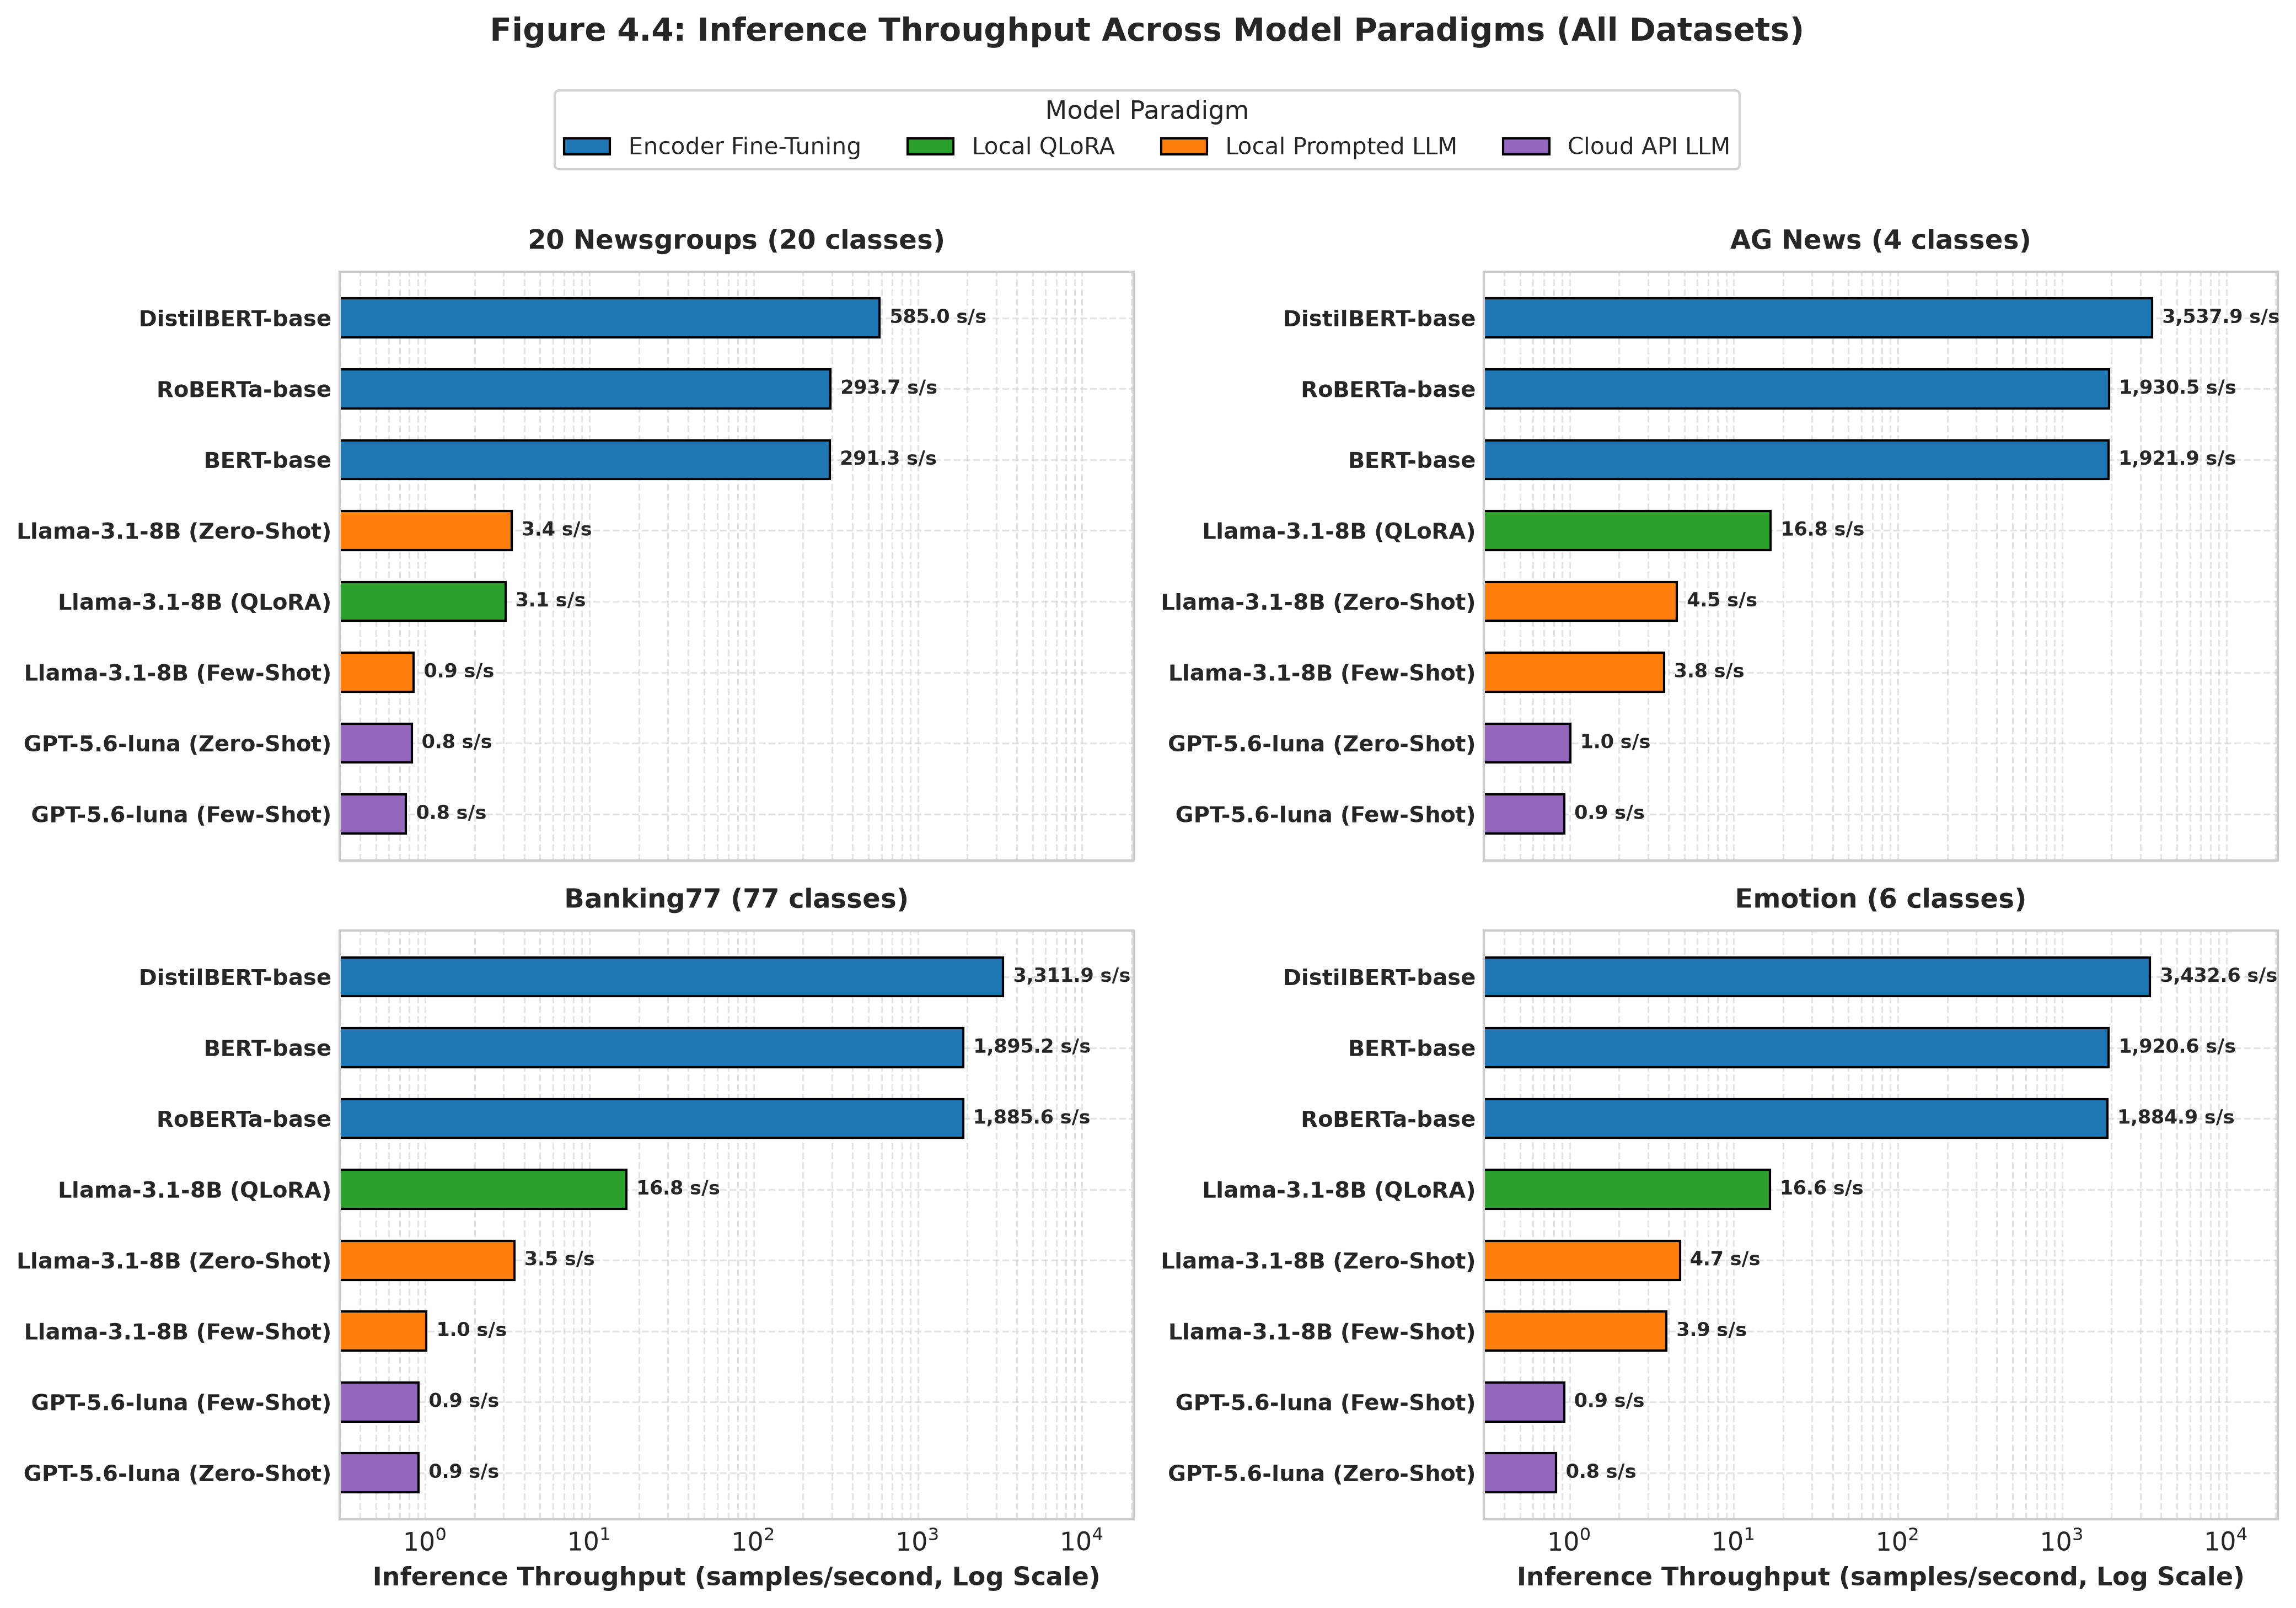

In [10]:
fig_tp_all = "../results/plots/fig4_4_throughput_all_datasets.png"
plot_inference_throughput(df, dataset_name='all', output_path=fig_tp_all)
display(Image(filename=fig_tp_all))


### 2.4 Cost Efficiency Metric Tables
Call `create_cost_efficiency_table(df, dataset_name)` to evaluate **Accuracy**, **Macro F1**, **Cost per Correct Prediction** ($USD$), and **Cost per 100 Million Predictions** ($USD$) alongside Latency.


In [11]:
print("=== COST EFFICIENCY: 20 NEWSGROUPS ===")
eff_20news = create_cost_efficiency_table(df, '20_newsgroups')
display(eff_20news)


=== COST EFFICIENCY: 20 NEWSGROUPS ===


Accuracy Macro F1  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                  0.7232   0.7029   
                    DistilBERT-base            0.7099   0.6856   
                    RoBERTa-base               0.7312   0.7125   
Local QLoRA         Llama-3.1-8B (QLoRA)       0.8008   0.7901   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)    0.2463   0.2477   
                    Llama-3.1-8B (Zero-Shot)   0.4006   0.3587   
Cloud API LLM       GPT-5.6-luna (Few-Shot)    0.7770   0.7675   
                    GPT-5.6-luna (Zero-Shot)   0.7615   0.7495   

                                             Inference Latency (ms/sample)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                      3.43 ms   
                    DistilBERT-base                                1.71 ms   
                    RoBERTa-base                                   3.40 ms   
Local QLoRA         Llama-3.1-8B (QLoRA)                         325.27 ms   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                     1174.96 ms   
                    Llama-3.1-8B (Zero-Shot)                     298.38 ms   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                     1308.70 ms   
                    GPT-5.6-luna (Zero-Shot)                    1210.33 ms   

                                             Cost per Correct Pred ($ USD)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                    $0.000000   
                    DistilBERT-base                              $0.000000   
                    RoBERTa-base                                 $0.000000   
Local QLoRA         Llama-3.1-8B (QLoRA)                         $0.000001   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      $0.000014   
                    Llama-3.1-8B (Zero-Shot)                     $0.000002   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                      $0.000974   
                    GPT-5.6-luna (Zero-Shot)                     $0.000173   

                                             Cost per 100M Pred ($ USD)  
Paradigm            Model                                                
Encoder Fine-Tuning BERT-base                                     $0.89  
                    DistilBERT-base                               $0.41  
                    RoBERTa-base                                  $0.83  
Local QLoRA         Llama-3.1-8B (QLoRA)                         $85.15  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                     $350.33  
                    Llama-3.1-8B (Zero-Shot)                     $73.51  
Cloud API LLM       GPT-5.6-luna (Few-Shot)                  $75,657.06  
                    GPT-5.6-luna (Zero-Shot)                 $13,159.72

In [12]:
print("=== COST EFFICIENCY: AG NEWS ===")
eff_agnews = create_cost_efficiency_table(df, 'ag_news')
display(eff_agnews)


=== COST EFFICIENCY: AG NEWS ===


Accuracy Macro F1  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                  0.9457   0.9458   
                    DistilBERT-base            0.9442   0.9442   
                    RoBERTa-base               0.9499   0.9499   
Local QLoRA         Llama-3.1-8B (QLoRA)       0.9528   0.9528   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)    0.7918   0.7794   
                    Llama-3.1-8B (Zero-Shot)   0.7478   0.7415   
Cloud API LLM       GPT-5.6-luna (Few-Shot)    0.8667   0.8649   
                    GPT-5.6-luna (Zero-Shot)   0.8657   0.8643   

                                             Inference Latency (ms/sample)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                      0.52 ms   
                    DistilBERT-base                                0.28 ms   
                    RoBERTa-base                                   0.52 ms   
Local QLoRA         Llama-3.1-8B (QLoRA)                          59.55 ms   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      266.22 ms   
                    Llama-3.1-8B (Zero-Shot)                     222.00 ms   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                     1075.89 ms   
                    GPT-5.6-luna (Zero-Shot)                     991.95 ms   

                                             Cost per Correct Pred ($ USD)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                    $0.000000   
                    DistilBERT-base                              $0.000000   
                    RoBERTa-base                                 $0.000000   
Local QLoRA         Llama-3.1-8B (QLoRA)                         $0.000000   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      $0.000001   
                    Llama-3.1-8B (Zero-Shot)                     $0.000001   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                      $0.000096   
                    GPT-5.6-luna (Zero-Shot)                     $0.000044   

                                             Cost per 100M Pred ($ USD)  
Paradigm            Model                                                
Encoder Fine-Tuning BERT-base                                     $0.10  
                    DistilBERT-base                               $0.05  
                    RoBERTa-base                                  $0.09  
Local QLoRA         Llama-3.1-8B (QLoRA)                         $14.42  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      $59.98  
                    Llama-3.1-8B (Zero-Shot)                     $43.21  
Cloud API LLM       GPT-5.6-luna (Few-Shot)                   $8,312.12  
                    GPT-5.6-luna (Zero-Shot)                  $3,826.62

In [13]:
print("=== COST EFFICIENCY: BANKING77 ===")
eff_banking = create_cost_efficiency_table(df, 'banking77')
display(eff_banking)


=== COST EFFICIENCY: BANKING77 ===


Accuracy Macro F1  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                  0.8540   0.8395   
                    DistilBERT-base            0.8287   0.8181   
                    RoBERTa-base               0.9122   0.9110   
Local QLoRA         Llama-3.1-8B (QLoRA)       0.9441   0.9441   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)    0.6482   0.6420   
                    Llama-3.1-8B (Zero-Shot)   0.4506   0.4287   
Cloud API LLM       GPT-5.6-luna (Few-Shot)    0.8846   0.8830   
                    GPT-5.6-luna (Zero-Shot)   0.8521   0.8442   

                                             Inference Latency (ms/sample)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                      0.53 ms   
                    DistilBERT-base                                0.30 ms   
                    RoBERTa-base                                   0.53 ms   
Local QLoRA         Llama-3.1-8B (QLoRA)                          59.63 ms   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      984.05 ms   
                    Llama-3.1-8B (Zero-Shot)                     286.82 ms   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                     1096.45 ms   
                    GPT-5.6-luna (Zero-Shot)                    1096.88 ms   

                                             Cost per Correct Pred ($ USD)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                    $0.000000   
                    DistilBERT-base                              $0.000000   
                    RoBERTa-base                                 $0.000000   
Local QLoRA         Llama-3.1-8B (QLoRA)                         $0.000000   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      $0.000005   
                    Llama-3.1-8B (Zero-Shot)                     $0.000002   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                      $0.000670   
                    GPT-5.6-luna (Zero-Shot)                     $0.000181   

                                             Cost per 100M Pred ($ USD)  
Paradigm            Model                                                
Encoder Fine-Tuning BERT-base                                     $0.07  
                    DistilBERT-base                               $0.03  
                    RoBERTa-base                                  $0.08  
Local QLoRA         Llama-3.1-8B (QLoRA)                         $15.19  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                     $302.80  
                    Llama-3.1-8B (Zero-Shot)                     $77.91  
Cloud API LLM       GPT-5.6-luna (Few-Shot)                  $59,256.76  
                    GPT-5.6-luna (Zero-Shot)                 $15,392.17

In [14]:
print("=== COST EFFICIENCY: EMOTION ===")
eff_emotion = create_cost_efficiency_table(df, 'emotion')
display(eff_emotion)


=== COST EFFICIENCY: EMOTION ===


Accuracy Macro F1  \
Paradigm            Model                                        
Encoder Fine-Tuning BERT-base                  0.9277   0.8797   
                    DistilBERT-base            0.9260   0.8791   
                    RoBERTa-base               0.9308   0.8916   
Local QLoRA         Llama-3.1-8B (QLoRA)       0.9340   0.8920   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)    0.4560   0.4039   
                    Llama-3.1-8B (Zero-Shot)   0.5315   0.4500   
Cloud API LLM       GPT-5.6-luna (Few-Shot)    0.6130   0.5528   
                    GPT-5.6-luna (Zero-Shot)   0.6520   0.5888   

                                             Inference Latency (ms/sample)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                      0.52 ms   
                    DistilBERT-base                                0.22 ms   
                    RoBERTa-base                                   0.53 ms   
Local QLoRA         Llama-3.1-8B (QLoRA)                          60.33 ms   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      257.01 ms   
                    Llama-3.1-8B (Zero-Shot)                     212.79 ms   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                     1079.98 ms   
                    GPT-5.6-luna (Zero-Shot)                    1213.05 ms   

                                             Cost per Correct Pred ($ USD)  \
Paradigm            Model                                                    
Encoder Fine-Tuning BERT-base                                    $0.000000   
                    DistilBERT-base                              $0.000000   
                    RoBERTa-base                                 $0.000000   
Local QLoRA         Llama-3.1-8B (QLoRA)                         $0.000000   
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      $0.000001   
                    Llama-3.1-8B (Zero-Shot)                     $0.000001   
Cloud API LLM       GPT-5.6-luna (Few-Shot)                      $0.000158   
                    GPT-5.6-luna (Zero-Shot)                     $0.000096   

                                             Cost per 100M Pred ($ USD)  
Paradigm            Model                                                
Encoder Fine-Tuning BERT-base                                     $0.10  
                    DistilBERT-base                               $0.02  
                    RoBERTa-base                                  $0.07  
Local QLoRA         Llama-3.1-8B (QLoRA)                         $15.28  
Local Prompted LLM  Llama-3.1-8B (Few-Shot)                      $60.47  
                    Llama-3.1-8B (Zero-Shot)                     $42.38  
Cloud API LLM       GPT-5.6-luna (Few-Shot)                   $9,668.25  
                    GPT-5.6-luna (Zero-Shot)                  $6,260.55

### 2.5 Figure 4.5: Cost vs. Macro F1 Pareto Frontiers Across All Datasets
Unified diagram with all datasets in one place:
- **Y-Axis**: Macro F1 Score ($0.0 - 1.0$)
- **X-Axis**: Cost per Correct Prediction ($USD$, log scale)
- **Markers**: Same shape for same model family, distinct colors for Zero-Shot and Few-Shot
- **Step Line**: Red dashed Pareto Frontier
- **Styling**: Gridlines removed, legend positioned at bottom


Saved Unified Pareto Frontier plot to: ../results/plots/fig4_5_pareto_all_datasets.png


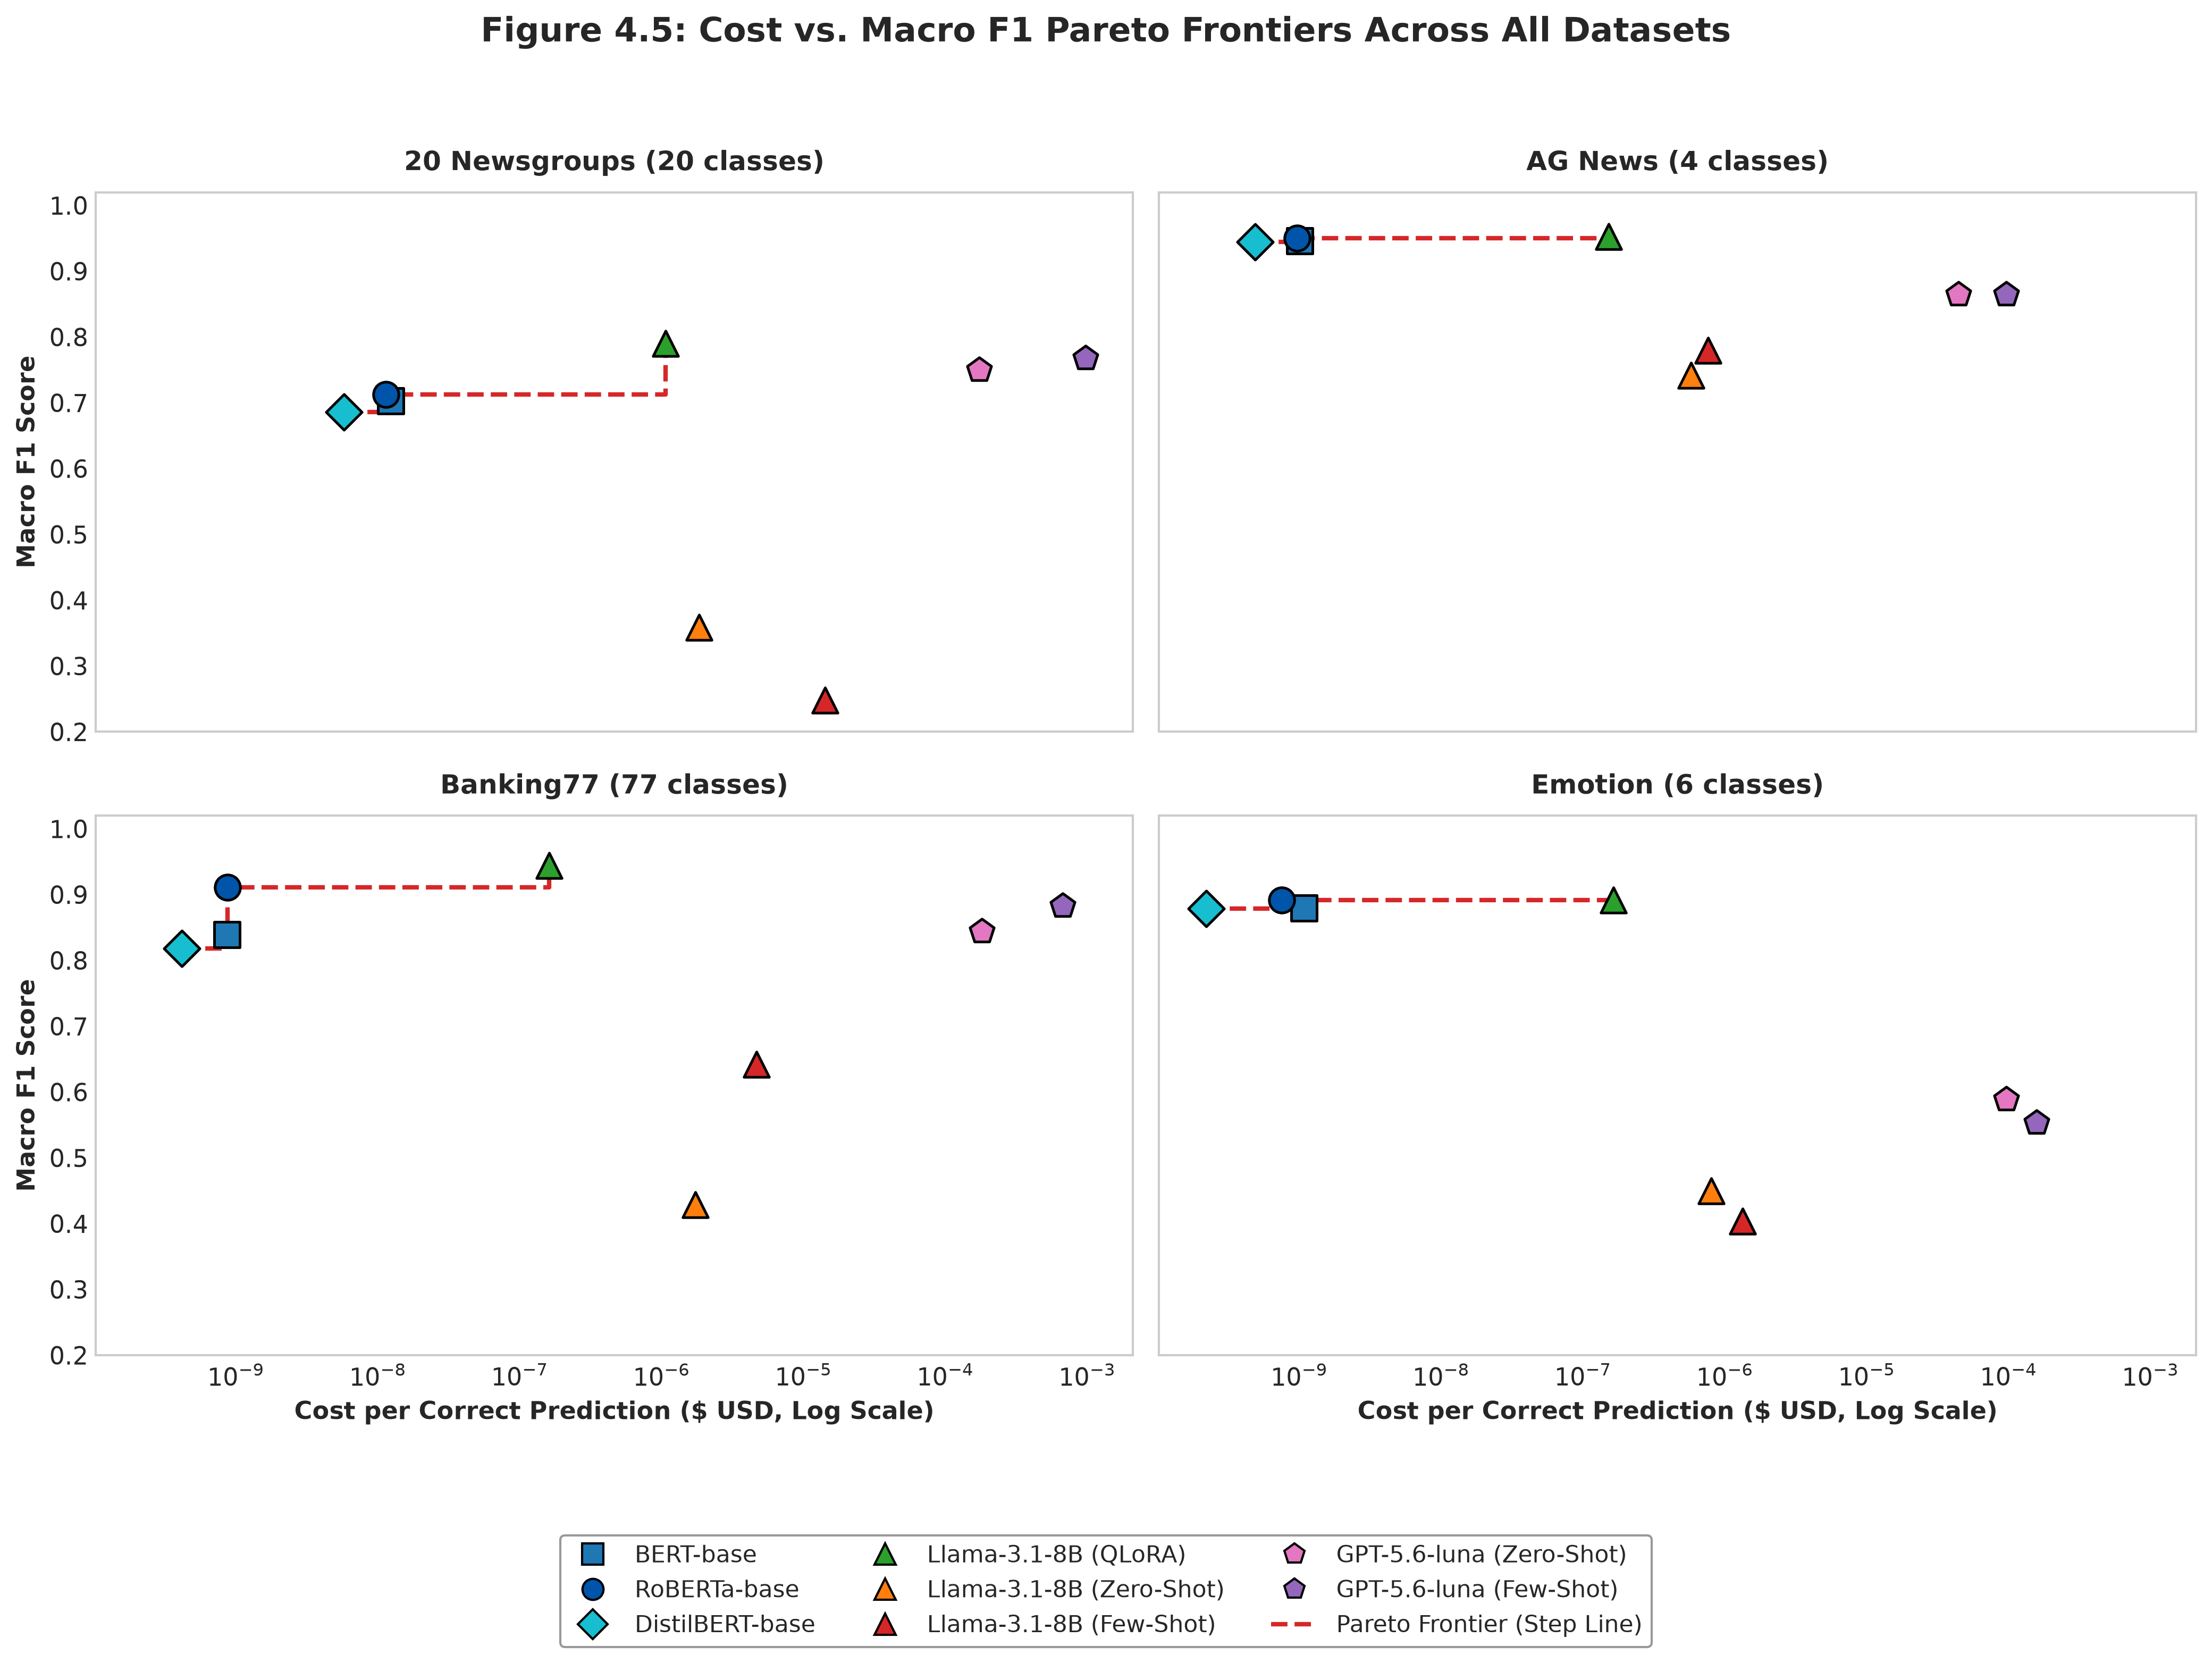

In [15]:
pareto_path_all = "../results/plots/fig4_5_pareto_all_datasets.png"
plot_pareto_cost_vs_accuracy(df, dataset_name='all', output_path=pareto_path_all)
display(Image(filename=pareto_path_all))
